# 7. Single-cell heterogeneity

A well median summarizes a population that is rarely uniform. If a fifth of the cells respond
strongly and the rest do not respond, the median reports a mild effect, and the fact that
there are two populations is lost before analysis starts.

This page works on single cells to show what the median hides.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc

import mantispy as mt

## A plate with a partial responder

The plate has no injected effect except that 20% of one perturbation's cells are shifted
strongly. Everything else is noise.

In [2]:
cells = mt.ds.synthetic_plate(n_wells=96, n_cells=60, n_features=25, n_perturbations=2, effect_size=0.0, seed=0)
mt.pp.normalize(cells, by="Metadata_Plate", reference="negcon", keep_raw=True)

rng = np.random.default_rng(0)
target = np.flatnonzero((cells.obs["Metadata_Perturbation"] == "pert00").to_numpy())
responders = rng.choice(target, size=int(0.2 * target.size), replace=False)
values = cells.X.copy()
values[responders] += 8.0
cells.X = values

cells.obs["is_responder"] = False
cells.obs.iloc[responders, cells.obs.columns.get_loc("is_responder")] = True
cells

AnnData object with n_obs × n_vars = 5760 × 25
    obs: 'Metadata_Plate', 'Metadata_Well', 'Metadata_Row', 'Metadata_Col', 'Metadata_Perturbation', 'Metadata_Control', 'Metadata_Batch', 'Metadata_ImageNumber', 'Metadata_CellCount', 'is_responder'
    var: 'object', 'feature_group', 'feature', 'channel', 'scale', 'angle', 'gray_levels', 'radial_bin', 'params', 'is_feature', 'degenerate_scale'
    uns: 'mantispy'
    layers: None (.X), 'raw'

## What aggregation costs

Aggregate to wells and compare. At cell level the responders sit eight times further from
the origin than the unshifted cells in the same wells. After taking the median, the whole
perturbation is only about twice as far out as the controls, a mild effect of the size a
plate artifact could produce.

In [3]:
wells = mt.tl.aggregate(cells, min_cells=0)

cell_magnitude = np.linalg.norm(np.asarray(cells.X, dtype=float), axis=1)
well_magnitude = np.linalg.norm(np.asarray(wells.X, dtype=float), axis=1)
rest = np.setdiff1d(target, responders)

{
    "cells, responders": round(float(cell_magnitude[responders].mean()), 2),
    "cells, the other 80% of pert00": round(float(cell_magnitude[rest].mean()), 2),
    "well medians, pert00": round(
        float(well_magnitude[(wells.obs["Metadata_Perturbation"] == "pert00").to_numpy()].mean()), 2
    ),
    "well medians, controls": round(
        float(well_magnitude[(wells.obs["Metadata_Perturbation"] == "DMSO").to_numpy()].mean()), 2
    ),
}

{'cells, responders': 40.23,
 'cells, the other 80% of pert00': 5.01,
 'well medians, pert00': 1.84,
 'well medians, controls': 0.8}

## Working at this scale

A real screen has a million cells by four thousand features, which is 16 GB of float32 before
any transform allocates its output. `pp.downsample` caps the number of cells per group (by
default per well), so the densest wells do not dominate, and `stratify` keeps rare
perturbations represented.

Explore on a sample, then confirm on the full data.

In [4]:
small = mt.pp.downsample(cells, n_per_group=15)
{
    "before": (cells.n_obs, cells.n_vars),
    "after": (small.n_obs, small.n_vars),
    "megabytes": (round(cells.n_obs * cells.n_vars * 4 / 1e6, 1), round(small.n_obs * small.n_vars * 4 / 1e6, 1)),
    "wells still represented": int(small.obs.groupby(["Metadata_Plate", "Metadata_Well"], observed=True).ngroups),
}

{'before': (5760, 25),
 'after': (1440, 25),
 'megabytes': (0.6, 0.1),
 'wells still represented': 96}

## Cell states, and what changed about them

Clustering uses scanpy. `tl.cluster_composition` then turns the cluster labels into an object
whose rows are wells, whose columns are cell states, and whose values are the fraction of that
well's cells in each state.

This is an ordinary mantispy object, so `tl.map`, `pp.normalize` and the plotting functions
work on cell-state composition as they do on features.

In [5]:
sc.pp.pca(cells, n_comps=10)
sc.pp.neighbors(cells)
sc.tl.leiden(cells, key_added="leiden", flavor="igraph", n_iterations=2)

composition = mt.tl.cluster_composition(cells)
by_group = pd.DataFrame(np.asarray(composition.X), columns=list(composition.var_names))
by_group["group"] = composition.obs["Metadata_Perturbation"].astype(str).to_numpy()

responder_cluster = cells.obs.loc[cells.obs["is_responder"], "leiden"].value_counts()
responder_cluster = responder_cluster[responder_cluster > 0]
{
    "composition object": composition.shape,
    "clusters holding the responders": responder_cluster.to_dict(),
    "control cells in that cluster": int(
        ((cells.obs["leiden"] == responder_cluster.index[0]) & cells.obs["Metadata_Control"]).sum()
    ),
    "fraction of pert00 in that cluster": round(
        float(by_group.groupby("group").mean().loc["pert00", responder_cluster.index[0]]), 3
    ),
    "fraction of the controls in that cluster": round(
        float(by_group.groupby("group").mean().loc["DMSO", responder_cluster.index[0]]), 3
    ),
}

/Users/tim.treis/Library/Application Support/hatch/env/virtual/mantispy/IN9GYQN4/tutorials/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'composition object': (96, 16),
 'clusters holding the responders': {'15': 384},
 'control cells in that cluster': 0,
 'fraction of pert00 in that cluster': 0.2,
 'fraction of the controls in that cluster': 0.0}

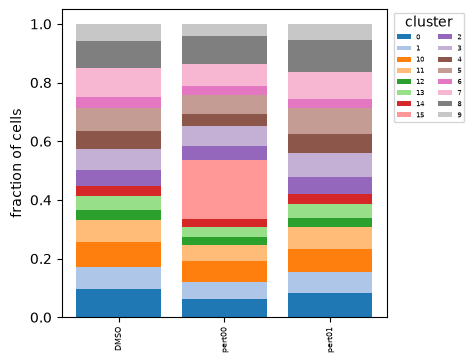

In [6]:
ax = mt.pl.cluster_composition(composition)
plt.show()

Every responder lands in one cluster, that cluster holds no control cells, and pert00's
composition in it reads 0.20, the fraction that was made to respond, recovered without being
given. The stacked bars show it as a band present in one group and absent from the others.

Sixteen clusters came out, and only one of them reflects a real difference. The plate has no
injected biology apart from the responders, so the other fifteen are leiden partitioning
Gaussian noise. Clustering always returns clusters. What distinguishes a cell state from a
partition of noise is whether the composition differs between conditions, which is what the
composition object measures.

## Two different questions

`cluster_composition` asks whether the mix of cell states changed. `tl.subpopulation_hits`
asks whether, within a state that treated and control cells share, the treated cells differ
from the controls.

On this plate the answer to the second question is no, which is correct. The responders left
the shared states and formed their own, so there is no difference left inside any state that
contains controls.

In [7]:
mt.tl.subpopulation_hits(cells, use_rep="X_pca")
table = cells.uns["mantispy"]["subpopulation_hits"]
{"tests": len(table), "significant": int((table["qvalue"] < 0.05).sum())}

{'tests': 45, 'significant': 0}

`subpopulation_hits` is meant for a different case: a shift small enough that the cells stay
in their states, applied to every cell of a perturbation instead of a fifth of them.

In [8]:
shifted = mt.ds.synthetic_plate(n_wells=96, n_cells=60, n_features=25, n_perturbations=2, effect_size=0.0, seed=0)
mt.pp.normalize(shifted, by="Metadata_Plate", reference="negcon")
values = shifted.X.copy()
weak = (shifted.obs["Metadata_Perturbation"] == "pert01").to_numpy()
values[weak, :5] += 0.8
shifted.X = values

sc.pp.pca(shifted, n_comps=10)
sc.pp.neighbors(shifted)
sc.tl.leiden(shifted, key_added="leiden", flavor="igraph", n_iterations=2)
mt.tl.subpopulation_hits(shifted, use_rep="X_pca")

table = shifted.uns["mantispy"]["subpopulation_hits"]
{
    "tests": len(table),
    "significant": int((table["qvalue"] < 0.05).sum()),
    "mean KS statistic per group": table.groupby("group")["statistic"].mean().round(3).to_dict(),
    "significant per group": table.loc[table["qvalue"] < 0.05, "group"].astype(str).value_counts().to_dict(),
}

{'tests': 63,
 'significant': 3,
 'mean KS statistic per group': {'DMSO': 0.248,
  'pert00': 0.167,
  'pert01': 0.246},
 'significant per group': {'pert01': 3}}

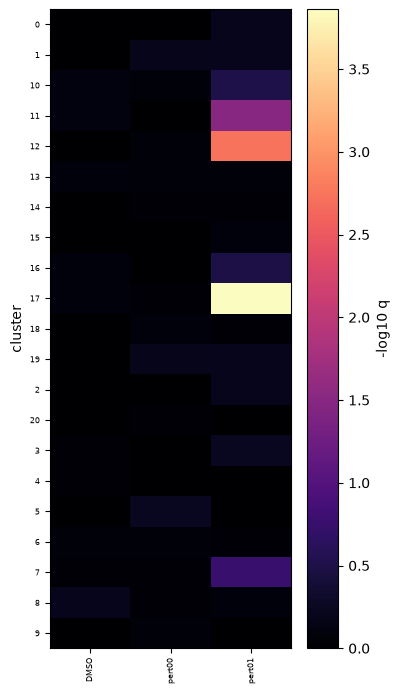

In [9]:
ax = mt.pl.subpopulation_hits(shifted)
plt.show()

All three significant tests belong to the shifted perturbation, and none to the unchanged one.
Look at the significance calls rather than the means: the mean KS statistics are 0.25 for the shifted perturbation against
0.17 for the unchanged one, a real but modest gap, because a shift small enough to keep cells inside their states
moves every cluster only a little. The test separates the two.

The statistic is a KS test on each cell's distance to the control center of its own cluster,
so each cell is compared with controls in the same state.

DMSO's own mean, 0.25, is not comparable with the others and is not a sign that the controls moved.
The controls fill three roles here: half place each cluster's center, and the remaining half is split again into the cells tested and the cells they are tested against, so that row is a null draw from a quarter of the controls.
A KS statistic grows as the samples shrink, which is why a quarter of the controls scores higher than a whole perturbation does.

## Cell cycle

Much of the heterogeneity in a Cell Painting image comes from the cell cycle, so label it
before attributing variation to a treatment. `tl.cell_cycle_phase` fits a two-component
mixture to log integrated DNA intensity per plate. The lower component is G1, the upper is
G2M, and cells that neither component claims with confidence are called S.

It needs raw intensities. After normalization the values are z-scores, about half of them
negative, so there is no logarithm to take, and the function raises an error instead of
returning meaningless labels.

In [10]:
raw = cells.layers["raw"].copy()
raw[:, 0] = np.where(rng.random(cells.n_obs) < 0.4, 2.0, 1.0) + rng.normal(0, 0.05, cells.n_obs)
cells.layers["raw"] = raw

mt.tl.cell_cycle_phase(cells, dna_feature=cells.var_names[0], layer="raw")
cells.obs["Metadata_CellCyclePhase"].value_counts().to_dict()

{'G1': 3437, 'G2M': 2323, 'S': 0}

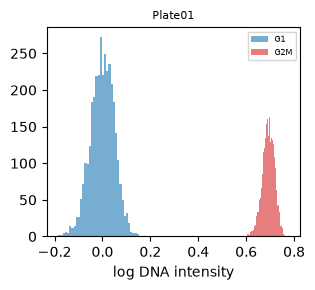

In [11]:
axes = mt.pl.cell_cycle(cells, dna_feature=cells.var_names[0], layer="raw")
plt.show()

40% of the cells were given twice the DNA content, and the assignment recovers that. Check
the plot before using the labels: two separate peaks with the colors split between them means
the fit worked, and a single smeared distribution means it did not, regardless of the counts.
This is a heuristic, and it cannot tell G0 from G1.

No cells are called S here because the demo feature was built as two point masses, with
nothing between the peaks. A real asynchronous culture has a broad S shoulder between G1 and
G2M and a substantial S fraction, and the S calls come from that shoulder. Set `dna_feature`
to an integrated nuclear DNA intensity (`Nuclei_Intensity_IntegratedIntensity_DNA` in a
standard Cell Painting run) rather than whichever column happens to come first.

## Crowding

A cell in a dense field looks different from an isolated one regardless of treatment.
`tl.neighbors_local_density` measures crowding as the mean distance to the *k* nearest cells
in the same field of view (never across fields), and `pp.regress_out` removes it.

In [12]:
cells.obs["Metadata_Center_X"] = rng.uniform(0, 1000, cells.n_obs)
cells.obs["Metadata_Center_Y"] = rng.uniform(0, 1000, cells.n_obs)
mt.tl.neighbors_local_density(cells, k=10)

before = float(np.corrcoef(cells.obs["Metadata_LocalDensity"], np.asarray(cells.X, dtype=float)[:, 1])[0, 1])
mt.pp.regress_out(cells, keys=["Metadata_LocalDensity"], by="Metadata_Plate")
after = float(np.corrcoef(cells.obs["Metadata_LocalDensity"], np.asarray(cells.X, dtype=float)[:, 1])[0, 1])
{"correlation with local density, before": round(before, 4), "after": round(after, 4)}

{'correlation with local density, before': -0.0084, 'after': 0.0}

The coordinates here are random, so there is no crowding effect to remove and the correlation
was near zero to begin with. On real data it is not. `mt.io.read_profiles` keeps the centroid
columns this step needs.

## Summary

- Aggregate late. A well median dilutes a partial response by the fraction of cells that did
  not respond, and no downstream method can recover it.
- Composition and within-state testing answer different questions, and an experiment
  usually needs both.
- Cell-state fractions are a feature matrix like any other, so the rest of mantispy works on
  them.

Next: [8. Trustworthy features and design](08_trustworthy_features_and_design.ipynb), on
which features are reproducible across replicates, how many replicates the next screen needs,
and how to tell a hit from a compound that killed the cells.